# Unidade VI — Análise de Grupos

## Agrupamento hierárquico

**Carga estimada:** 1,5 hora  
**Pré-requisitos:** distância, padronização e fundamentos de análise de grupos.

> **Pergunta norteadora:** como representar agrupamentos em diferentes níveis de granularidade e compreender sequências de fusões ou divisões?

Este notebook introduz as estratégias aglomerativa e divisiva. Em seguida, desenvolve a estratégia aglomerativa por meio dos critérios de ligação, dos dendrogramas e do critério de Ward.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir estratégias aglomerativas e divisivas;
- explicar ligações simples, completa, média e Ward;
- ler folhas, fusões e alturas em um dendrograma;
- produzir uma partição por corte horizontal;
- relacionar Ward à variação da SSE;
- reconhecer decisões irreversíveis e sensibilidade à distância.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

## 1. Por que construir uma hierarquia?

Uma partição mostra apenas um nível de detalhe. Uma hierarquia permite observar grandes segmentos e, dentro deles, subgrupos. Ela pode representar uma estrutura substantiva ou funcionar apenas como instrumento de resumo e exploração.

Há duas direções para construir essa árvore:

- **Aglomerativa (*bottom-up*, de baixo para cima):** começa com um grupo por objeto e funde os dois grupos mais próximos a cada etapa. Depois de uma fusão, ela não é desfeita.
- **Divisiva (*top-down*, de cima para baixo):** começa com todos os objetos em um único grupo e divide um grupo por vez. Depois de uma divisão, os ramos normalmente não voltam a ser reunidos.

Portanto, a aglomerativa pergunta **“quais grupos devem ser unidos agora?”**, enquanto a divisiva pergunta **“qual grupo deve ser separado agora e como?”**. Ambas produzem uma hierarquia, mas tomam decisões em sentidos opostos.

A parte prática deste notebook utiliza a estratégia aglomerativa, que é a mais comum nas bibliotecas introdutórias. Antes disso, detalharemos como funciona a alternativa divisiva.

### 1.1 Estratégia divisiva (*top-down*) passo a passo

Um método divisivo mantém uma lista dos grupos existentes. Em cada iteração, ele:

1. **seleciona um grupo para dividir**, geralmente aquele com maior heterogeneidade, diâmetro ou SSE;
2. **separa esse grupo em dois ou mais subgrupos**, usando um critério de dissimilaridade;
3. **avalia a divisão**, verificando se ela melhora a homogeneidade e se respeita restrições como tamanho mínimo;
4. **repete o processo** em algum dos grupos resultantes até atingir uma condição de parada.

Uma divisão pode ser produzida de diferentes maneiras. Duas possibilidades importantes são:

- **DIANA (*Divisive Analysis*):** no grupo selecionado, um objeto muito diferente dos demais inicia um “grupo dissidente”. Outros objetos podem ser transferidos para esse novo grupo quando forem, em média, mais próximos dele do que do grupo original. O processo gera uma divisão e depois continua recursivamente.
- **k-means bissector:** executa k-means com $k=2$ apenas sobre o grupo escolhido, possivelmente várias vezes, e mantém uma boa bipartição. É uma estratégia divisiva, embora use k-means como procedimento interno.

Ao contrário da abordagem aglomerativa, o método divisivo não precisa escolher entre ligação simples, completa, média ou Ward para decidir uma **fusão**. Ele precisa definir dois outros critérios: **qual grupo dividir** e **como realizar a divisão**.

#### Exemplo conceitual

Suponha oito objetos inicialmente reunidos. O grupo completo apresenta três regiões bem diferenciadas. Uma execução divisiva possível seria:

| Etapa | Grupo escolhido | Divisão realizada | Grupos existentes |
|---:|---|---|---|
| 0 | — | — | $\{A,B,C,D,E,F,G,H\}$ |
| 1 | $\{A,B,C,D,E,F,G,H\}$ | $\{A,B,C\}$ e $\{D,E,F,G,H\}$ | 2 grupos |
| 2 | $\{D,E,F,G,H\}$ | $\{D,E\}$ e $\{F,G,H\}$ | 3 grupos |

A árvore foi construída de cima para baixo:

```text
{A, B, C, D, E, F, G, H}
├── {A, B, C}
└── {D, E, F, G, H}
    ├── {D, E}
    └── {F, G, H}
```

Se o objetivo for obter três grupos, o algoritmo pode parar depois da segunda divisão. Outras condições de parada incluem atingir um diâmetro máximo aceitável, não encontrar uma divisão suficientemente útil ou evitar grupos menores que um limite definido.

#### Comparação direta

| Aspecto | Aglomerativa (*bottom-up*) | Divisiva (*top-down*) |
|---|---|---|
| Estado inicial | Um grupo para cada objeto | Um grupo contendo todos os objetos |
| Operação principal | Fundir grupos | Dividir grupos |
| Decisão central | Quais grupos estão mais próximos? | Qual grupo é mais heterogêneo e como separá-lo? |
| Critérios comuns | Ligações simples, completa, média e Ward | DIANA, bisseção por k-means ou outros critérios de corte |
| Irreversibilidade | Uma fusão não é revista | Uma divisão normalmente não é revista |
| Resultado | Dendrograma construído das folhas para a raiz | Dendrograma construído da raiz para as folhas |

O dendrograma pode representar as duas estratégias. O que muda é a direção da construção, não a possibilidade de ler níveis e obter uma partição por corte. Entretanto, métodos aglomerativos e divisivos podem produzir árvores diferentes sobre os mesmos dados, pois suas decisões locais e seus critérios não são equivalentes.

,x,y
A,0.0,0.0
B,0.3,0.2
C,0.2,0.8
D,2.5,2.2
E,2.9,2.4
F,5.2,0.2
G,5.6,0.5
H,5.3,1.0


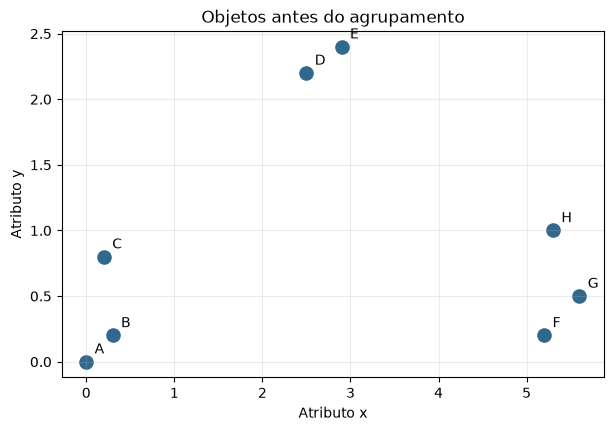

In [2]:
nomes = np.array(list("ABCDEFGH"))
X_h = np.array([
    [0.0, 0.0], [0.3, 0.2], [0.2, 0.8],
    [2.5, 2.2], [2.9, 2.4],
    [5.2, 0.2], [5.6, 0.5], [5.3, 1.0],
])
dados_h = pd.DataFrame(X_h, columns=["x", "y"], index=nomes)
display(dados_h)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_h[:, 0], X_h[:, 1], s=90, color="#31688e")
for nome, (x, y) in zip(nomes, X_h):
    ax.annotate(nome, (x, y), xytext=(6, 6), textcoords="offset points")
ax.set(title="Objetos antes do agrupamento", xlabel="Atributo x", ylabel="Atributo y")
ax.grid(alpha=0.25)
plt.show()

## 2. O que significa distância entre grupos?

O **critério de ligação** transforma as várias distâncias entre pares de pontos em uma distância entre grupos.

| Ligação | Definição | Tendência e atenção |
|---|---|---|
| simples | menor distância entre um ponto de cada grupo | encontra conexões locais; pode criar encadeamento |
| completa | maior distância entre um ponto de cada grupo | favorece grupos compactos; reage a pontos extremos |
| média | média das distâncias entre todos os pares | compromisso entre simples e completa |
| Ward | menor aumento da SSE pela fusão | favorece compactação; requer atributos numéricos e distância Euclidiana |

$$d_{simples}(C_i,C_j)=\min_{x\in C_i,y\in C_j}d(x,y),$$

$$d_{completa}(C_i,C_j)=\max_{x\in C_i,y\in C_j}d(x,y),$$

$$d_{média}(C_i,C_j)=\frac{1}{|C_i||C_j|}\sum_{x\in C_i}\sum_{y\in C_j}d(x,y).$$

Nenhuma ligação é universalmente melhor: cada uma operacionaliza uma ideia diferente de grupo.

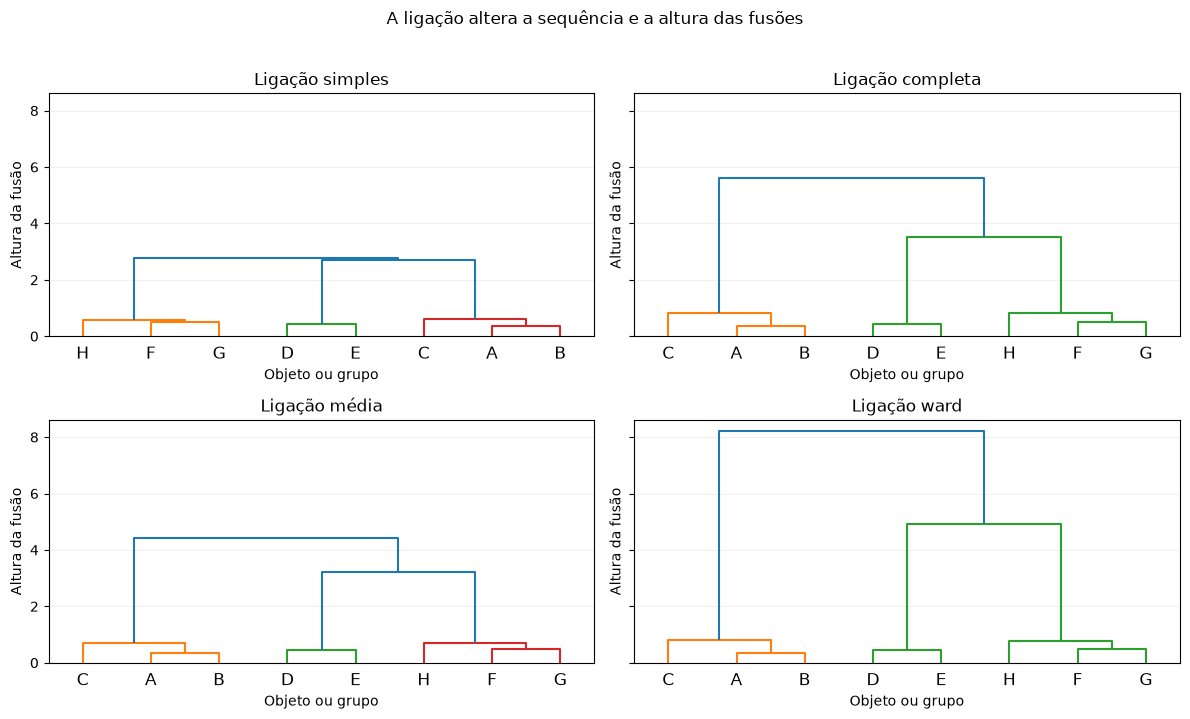

In [3]:
metodos = {"Simples": "single", "Completa": "complete", "Média": "average", "Ward": "ward"}
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for ax, (titulo, metodo) in zip(axes.ravel(), metodos.items()):
    Z = linkage(X_h, method=metodo, metric="euclidean")
    dendrogram(Z, labels=nomes.tolist(), ax=ax, color_threshold=None)
    ax.set(title=f"Ligação {titulo.lower()}", xlabel="Objeto ou grupo", ylabel="Altura da fusão")
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("A ligação altera a sequência e a altura das fusões", y=1.02)
fig.tight_layout()
plt.show()

## 3. Como ler um dendrograma

Leia o gráfico de baixo para cima:

1. as folhas são os objetos; sua ordem horizontal serve apenas para desenhar a árvore;
2. cada junção horizontal registra uma fusão;
3. a altura é o valor do critério na fusão — não é o tamanho do grupo;
4. um corte horizontal define uma partição: cada ramo interceptado corresponde a um grupo.

Um grande intervalo vertical pode sugerir um corte, mas não prova que o número de grupos seja útil. A decisão exige estabilidade, interpretação e finalidade.

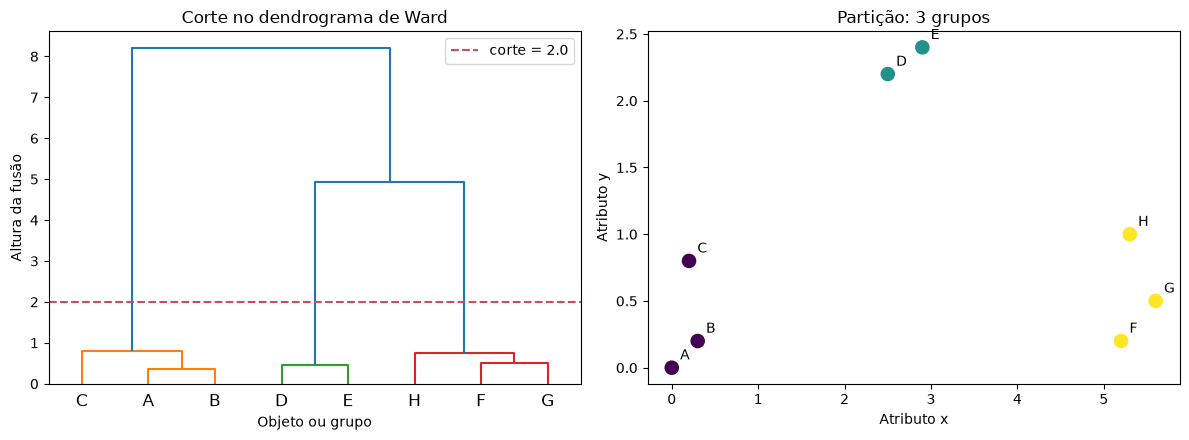

,objeto,grupo_no_corte
0,A,1
1,B,1
2,C,1
3,D,2
4,E,2
5,F,3
6,G,3
7,H,3


In [4]:
Z_ward = linkage(X_h, method="ward")
altura_corte = 2.0
rotulos_corte = fcluster(Z_ward, t=altura_corte, criterion="distance")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
dendrogram(Z_ward, labels=nomes.tolist(), ax=axes[0], color_threshold=altura_corte)
axes[0].axhline(altura_corte, color="#d1495b", linestyle="--", label=f"corte = {altura_corte}")
axes[0].set(title="Corte no dendrograma de Ward", xlabel="Objeto ou grupo", ylabel="Altura da fusão")
axes[0].legend()
axes[1].scatter(X_h[:, 0], X_h[:, 1], c=rotulos_corte, cmap="viridis", s=90)
for nome, (x, y) in zip(nomes, X_h):
    axes[1].annotate(nome, (x, y), xytext=(6, 6), textcoords="offset points")
axes[1].set(title=f"Partição: {len(np.unique(rotulos_corte))} grupos", xlabel="Atributo x", ylabel="Atributo y")
fig.tight_layout()
plt.show()
display(pd.DataFrame({"objeto": nomes, "grupo_no_corte": rotulos_corte}))

### Por que Ward se relaciona ao k-means?

Ward escolhe a fusão com o menor aumento da soma dos quadrados dentro dos grupos. Para tamanhos $n_i,n_j$ e médias $\boldsymbol{m}_i,\boldsymbol{m}_j$:

$$\Delta SSE(C_i,C_j)=\frac{n_i n_j}{n_i+n_j}\lVert\boldsymbol{m}_i-\boldsymbol{m}_j\rVert^2.$$

Assim como o k-means, Ward favorece grupos compactos. Ward preserva uma sequência de partições aninhadas; o k-means procura diretamente uma partição com $k$ grupos. Padronização continua necessária quando as escalas são incomparáveis.

## 4. Quando considerar agrupamento hierárquico

O método é útil para explorar níveis de granularidade, visualizar fusões e trabalhar com conjuntos em que uma árvore de relações é informativa. Distância e ligação precisam ser justificadas, e o custo pode limitar aplicações muito grandes.

O dendrograma não prova que exista uma taxonomia natural. Cortes próximos, estabilidade, tamanhos, perfis e finalidade devem participar da escolha.

## 5. Atividades

**U06-NB02-V01.** Um dendrograma de ligação completa apresenta uma fusão na altura 4,2. Explique o que esse número representa e por que ele não significa que o novo grupo possui 4,2 objetos.

**U06-NB02-E01.** Considere C1={A=(0,0),B=(0,1)} e C2={C=(4,0),D=(4,2)}. Calcule a distância entre os grupos pelas ligações simples, completa e média. Calcule também o aumento da SSE de Ward e explique por que os valores não precisam coincidir.

**U06-NB02-E02.** No dendrograma de Ward deste notebook, o corte na altura 2,0 gera quais grupos? Descreva a leitura visual e confirme-a pela tabela.

## 6. Síntese

- A hierarquia representa partições em diferentes níveis.
- A estratégia aglomerativa (*bottom-up*) realiza fusões; a divisiva (*top-down*) realiza divisões.
- Métodos divisivos precisam definir qual grupo separar, como separá-lo e quando parar.
- A ligação define o significado de distância entre grupos na estratégia aglomerativa.
- A altura do dendrograma registra o critério de fusão, não a quantidade de objetos.
- Um corte horizontal transforma a árvore em uma partição.
- Ward escolhe fusões com pequeno aumento da SSE e favorece grupos compactos.
- A árvore depende da representação, da distância e de decisões que não são revistas.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seção 8.3.
- SCIPY COMMUNITY. scipy.cluster.hierarchy. Documentação oficial.

Os dados e as figuras são autorais e gerados localmente.